# 01. Importação das bibliotecas

In [ ]:
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

#Configuração visual dos gráficos
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42

# 2. Localização e marcação do dataset

In [10]:
from pathlib import Path
import zipfile

zipPath = Path("../../data/raw/archive (4).zip")
extractArc = Path("../../data/raw/dataset_eeg_extraido")
extractArc.mkdir(parents=True, exist_ok=True)

#Extraindo o ZIP
with zipfile.ZipFile(zipPath, "r") as zip_ref:
    zip_ref.extractall(extractArc)

#Buscando os CSVs dentro da pasta eeg/
csv_files = sorted(extractArc.glob("eeg/*.csv"))

print(f"\nQuantidade de CSVs encontrados: {len(csv_files)}")

for file in csv_files:
    print("-", file)


Quantidade de CSVs encontrados: 5
- ..\..\data\raw\dataset_eeg_extraido\eeg\user_a.csv
- ..\..\data\raw\dataset_eeg_extraido\eeg\user_b.csv
- ..\..\data\raw\dataset_eeg_extraido\eeg\user_c.csv
- ..\..\data\raw\dataset_eeg_extraido\eeg\user_d.csv
- ..\..\data\raw\dataset_eeg_extraido\eeg\user_e.csv


# 3. Leitura dos arquivos na pasta consolidada

In [11]:
dfs = []

for file in csv_files:
    temp = pd.read_csv(file)
    temp["usuario"] = file.stem
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print("Dimensão final do dataset:", df.shape)
display(df.head())

Dimensão final do dataset: (85485, 27)


,Values,POW.AF3.Theta,POW.AF3.Alpha,POW.AF3.BetaL,POW.AF3.BetaH,POW.AF3.Gamma,POW.T7.Theta,POW.T7.Alpha,POW.T7.BetaL,POW.T7.BetaH,POW.T7.Gamma,POW.Pz.Theta,POW.Pz.Alpha,POW.Pz.BetaL,POW.Pz.BetaH,POW.Pz.Gamma,POW.T8.Theta,POW.T8.Alpha,POW.T8.BetaL,POW.T8.BetaH,POW.T8.Gamma,POW.AF4.Theta,POW.AF4.Alpha,POW.AF4.BetaL,POW.AF4.BetaH,POW.AF4.Gamma,usuario
0,0.0000,177.5451,44.2015,52.9014,111.8482,118.6306,146.5435,112.6737,73.0565,93.5288,92.6630,106.6866,82.9371,30.2349,77.4286,88.7888,38.6284,47.6198,11.6482,20.0131,20.7076,89.1888,74.4504,114.0570,35.0279,181.8550,user_a
1,0.0000,134.3939,36.7224,58.0606,138.9239,143.0860,125.9631,112.4389,80.6449,114.1508,110.3751,97.1164,82.7024,36.7431,96.0461,103.5271,35.0509,45.5862,14.2611,24.1600,24.5867,71.7877,65.9173,131.2529,42.4404,217.2875,user_a
2,0.0000,101.1792,32.5845,76.6646,157.9865,169.9485,105.9535,106.9954,92.9900,127.5711,127.9465,96.2774,89.6067,49.0432,113.0187,117.2420,31.2099,42.3978,18.1054,26.9553,28.5099,62.2860,66.6640,147.8408,51.1775,242.3189,user_a
3,0.0000,86.3726,32.8434,103.3081,163.5239,192.9138,89.3381,100.2641,103.9703,130.2801,142.1254,100.5089,102.8725,63.5678,125.1658,126.1135,28.7466,39.8314,22.1972,28.0149,31.6300,57.2043,78.5963,160.0717,59.7905,251.6138,user_a
4,0.0000,91.2199,38.4270,129.0150,155.1172,207.0573,78.0614,97.2153,108.9365,122.4675,150.6562,105.4616,119.5638,76.8121,130.5736,128.1994,29.7329,39.2641,25.6525,27.6710,33.3946,56.0114,98.6002,163.8230,67.0468,244.4874,user_a


In [12]:
display(df.info())

display(df.describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 85485 entries, 0 to 85484
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Values         85485 non-null  float64
 1   POW.AF3.Theta  85485 non-null  float64
 2   POW.AF3.Alpha  85485 non-null  float64
 3   POW.AF3.BetaL  85485 non-null  float64
 4   POW.AF3.BetaH  85485 non-null  float64
 5   POW.AF3.Gamma  85485 non-null  float64
 6   POW.T7.Theta   85485 non-null  float64
 7   POW.T7.Alpha   85485 non-null  float64
 8   POW.T7.BetaL   85485 non-null  float64
 9   POW.T7.BetaH   85485 non-null  float64
 10  POW.T7.Gamma   85485 non-null  float64
 11  POW.Pz.Theta   85485 non-null  float64
 12  POW.Pz.Alpha   85485 non-null  float64
 13  POW.Pz.BetaL   85485 non-null  float64
 14  POW.Pz.BetaH   85485 non-null  float64
 15  POW.Pz.Gamma   85485 non-null  float64
 16  POW.T8.Theta   85485 non-null  float64
 17  POW.T8.Alpha   85485 non-null  float64
 18  POW.T8.BetaL   85

None

,count,mean,std,min,25%,50%,75%,max
Values,"85,485.0000",0.9587,0.8014,0.0000,0.0000,1.0000,2.0000,2.0000
POW.AF3.Theta,"85,485.0000",70.3738,282.4030,0.1935,3.5289,7.9910,71.7304,"17,666.0176"
POW.AF3.Alpha,"85,485.0000",62.6338,161.1026,0.2047,2.1985,4.8070,26.7874,"6,095.2871"
POW.AF3.BetaL,"85,485.0000",39.4711,105.7856,0.0726,1.1133,1.7253,3.4736,"2,427.6826"
POW.AF3.BetaH,"85,485.0000",38.7463,92.9663,0.1992,0.8288,1.2315,2.2597,"1,587.7106"
POW.AF3.Gamma,"85,485.0000",29.8138,73.3034,0.0745,0.3266,0.5484,1.2893,"1,065.4773"
POW.T7.Theta,"85,485.0000",61.5544,324.5369,0.0659,0.6968,1.4273,8.6978,"13,075.5850"
POW.T7.Alpha,"85,485.0000",54.1325,171.1840,0.0662,0.5776,0.9881,4.2875,"7,881.7715"
POW.T7.BetaL,"85,485.0000",34.5381,99.8106,0.0639,0.4396,0.7904,2.8135,"2,688.7266"
POW.T7.BetaH,"85,485.0000",32.3055,80.1479,0.0945,0.4013,0.7356,4.1601,"1,809.5493"


In [13]:
target_col = "Values"
user_col = "usuario"

feature_cols = [col for col in df.columns if col not in [target_col, user_col]]

print("Coluna alvo:", target_col)
print("Coluna de usuário:", user_col)
print("Quantidade de features:", len(feature_cols))
print("Features:")
display(feature_cols)

Coluna alvo: Values
Coluna de usuário: usuario
Quantidade de features: 25
Features:


['POW.AF3.Theta',
 'POW.AF3.Alpha',
 'POW.AF3.BetaL',
 'POW.AF3.BetaH',
 'POW.AF3.Gamma',
 'POW.T7.Theta',
 'POW.T7.Alpha',
 'POW.T7.BetaL',
 'POW.T7.BetaH',
 'POW.T7.Gamma',
 'POW.Pz.Theta',
 'POW.Pz.Alpha',
 'POW.Pz.BetaL',
 'POW.Pz.BetaH',
 'POW.Pz.Gamma',
 'POW.T8.Theta',
 'POW.T8.Alpha',
 'POW.T8.BetaL',
 'POW.T8.BetaH',
 'POW.T8.Gamma',
 'POW.AF4.Theta',
 'POW.AF4.Alpha',
 'POW.AF4.BetaL',
 'POW.AF4.BetaH',
 'POW.AF4.Gamma']

In [14]:
feature_metadata = []

for col in feature_cols:
    parts = col.split(".")
    if len(parts) == 3:
        _, channel, band = parts
    else:
        channel, band = "desconhecido", "desconhecida"
    feature_metadata.append({"feature": col, "canal": channel, "banda": band})

feature_meta = pd.DataFrame(feature_metadata)

print("Canais encontrados:", sorted(feature_meta["canal"].unique()))
print("Bandas encontradas:", sorted(feature_meta["banda"].unique()))

display(feature_meta)

Canais encontrados: ['AF3', 'AF4', 'Pz', 'T7', 'T8']
Bandas encontradas: ['Alpha', 'BetaH', 'BetaL', 'Gamma', 'Theta']


,feature,canal,banda
0,POW.AF3.Theta,AF3,Theta
1,POW.AF3.Alpha,AF3,Alpha
2,POW.AF3.BetaL,AF3,BetaL
3,POW.AF3.BetaH,AF3,BetaH
4,POW.AF3.Gamma,AF3,Gamma
5,POW.T7.Theta,T7,Theta
6,POW.T7.Alpha,T7,Alpha
7,POW.T7.BetaL,T7,BetaL
8,POW.T7.BetaH,T7,BetaH
9,POW.T7.Gamma,T7,Gamma


In [15]:
quality_summary = pd.DataFrame({
    "coluna": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "nulos": df.isna().sum().values,
    "nulos_%": (df.isna().mean().values * 100),
    "unicos": df.nunique().values
})

display(quality_summary)

print("Total de valores nulos:", df.isna().sum().sum())
print("Total de linhas duplicadas:", df.duplicated().sum())
print("Existe infinito nas features?", np.isinf(df[feature_cols].to_numpy()).any())
print("Classes encontradas:", sorted(df[target_col].unique()))

,coluna,tipo,nulos,nulos_%,unicos
0,Values,float64,0,0.0000,3
1,POW.AF3.Theta,float64,0,0.0000,85308
2,POW.AF3.Alpha,float64,0,0.0000,85197
3,POW.AF3.BetaL,float64,0,0.0000,84642
4,POW.AF3.BetaH,float64,0,0.0000,84096
5,POW.AF3.Gamma,float64,0,0.0000,82814
6,POW.T7.Theta,float64,0,0.0000,84583
7,POW.T7.Alpha,float64,0,0.0000,84183
8,POW.T7.BetaL,float64,0,0.0000,83836
9,POW.T7.BetaH,float64,0,0.0000,83549


Total de valores nulos: 0
Total de linhas duplicadas: 0
Existe infinito nas features? False
Classes encontradas: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]


,quantidade_amostras
usuario,
user_a,15282
user_b,14946
user_c,21427
user_d,19133
user_e,14697


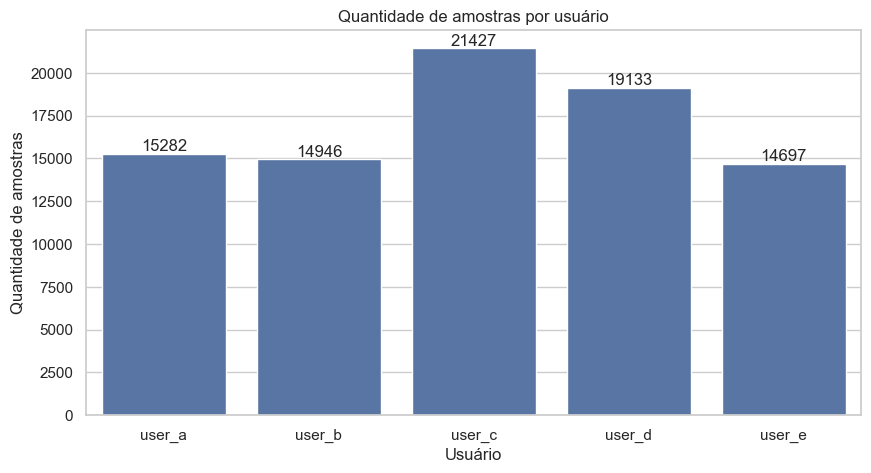

In [16]:
user_counts = df[user_col].value_counts().sort_index()

display(user_counts.to_frame("quantidade_amostras"))

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=user_counts.index, y=user_counts.values)
ax.set_title("Quantidade de amostras por usuário")
ax.set_xlabel("Usuário")
ax.set_ylabel("Quantidade de amostras")

for i, v in enumerate(user_counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.show()

,classe,quantidade,percentual
0,0.0000,29291,34.2600
1,1.0000,30433,35.6000
2,2.0000,25761,30.1400


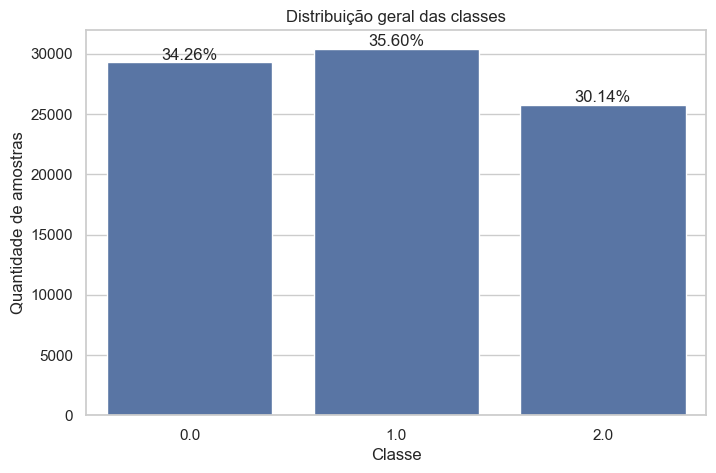

In [17]:
class_counts = df[target_col].value_counts().sort_index()
class_percent = (class_counts / class_counts.sum() * 100).round(2)

class_distribution = pd.DataFrame({
    "classe": class_counts.index,
    "quantidade": class_counts.values,
    "percentual": class_percent.values
})

display(class_distribution)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=class_distribution, x="classe", y="quantidade")
ax.set_title("Distribuição geral das classes")
ax.set_xlabel("Classe")
ax.set_ylabel("Quantidade de amostras")

for i, row in class_distribution.iterrows():
    ax.text(i, row["quantidade"], f'{row["percentual"]:.2f}%', ha="center", va="bottom")

plt.show()

In [ ]:
user_class_counts = pd.crosstab(df[user_col], df[target_col])
user_class_percent = pd.crosstab(df[user_col], df[target_col], normalize="index") * 100

display(user_class_counts)
display(user_class_percent.round(2))

plt.figure(figsize=(10, 6))
user_class_counts.plot(kind="bar", stacked=False, figsize=(12, 6))
plt.title("Distribuição das classes por usuário")
plt.xlabel("Usuário")
plt.ylabel("Quantidade de amostras")
plt.xticks(rotation=0)
plt.legend(title="Classe")
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(user_class_percent, annot=True, fmt=".1f", cmap="Blues")
plt.title("Percentual de classes por usuário")
plt.xlabel("Classe")
plt.ylabel("Usuário")
plt.show()

In [ ]:
feature_stats = df[feature_cols].agg(["min", "mean", "median", "std", "max"]).T
feature_stats["range"] = feature_stats["max"] - feature_stats["min"]

display(feature_stats.sort_values("std", ascending=False))

plt.figure(figsize=(14, 6))
sns.boxplot(data=df[feature_cols], orient="h")
plt.title("Boxplot das features EEG")
plt.xlabel("Valor")
plt.ylabel("Feature")
plt.show()

In [ ]:
df_long = df.melt(
    id_vars=[target_col, user_col],
    value_vars=feature_cols,
    var_name="feature",
    value_name="potencia"
)

df_long = df_long.merge(feature_meta, on="feature", how="left")

display(df_long.head())
print("Formato longo:", df_long.shape)

In [ ]:
band_summary = (
    df_long
    .groupby("banda")["potencia"]
    .agg(["mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(band_summary)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_long, x="banda", y="potencia", estimator=np.mean, errorbar=("ci", 95))
plt.title("Potência média por banda de frequência")
plt.xlabel("Banda")
plt.ylabel("Potência média")
plt.show()

In [ ]:
channel_summary = (
    df_long
    .groupby("canal")["potencia"]
    .agg(["mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(channel_summary)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_long, x="canal", y="potencia", estimator=np.mean, errorbar=("ci", 95))
plt.title("Potência média por canal EEG")
plt.xlabel("Canal")
plt.ylabel("Potência média")
plt.show()

In [ ]:
channel_band_mean = (
    df_long
    .groupby(["canal", "banda"])["potencia"]
    .mean()
    .reset_index()
    .pivot(index="canal", columns="banda", values="potencia")
)

display(channel_band_mean)

plt.figure(figsize=(10, 6))
sns.heatmap(channel_band_mean, annot=True, fmt=".1f", cmap="viridis")
plt.title("Potência média por canal e banda")
plt.xlabel("Banda")
plt.ylabel("Canal")
plt.show()

In [ ]:
class_band_mean = (
    df_long
    .groupby([target_col, "banda"])["potencia"]
    .mean()
    .reset_index()
)

display(class_band_mean)

plt.figure(figsize=(12, 6))
sns.barplot(data=class_band_mean, x="banda", y="potencia", hue=target_col)
plt.title("Potência média por banda e classe")
plt.xlabel("Banda")
plt.ylabel("Potência média")
plt.legend(title="Classe")
plt.show()

In [ ]:
class_channel_mean = (
    df_long
    .groupby([target_col, "canal"])["potencia"]
    .mean()
    .reset_index()
)

display(class_channel_mean)

plt.figure(figsize=(12, 6))
sns.barplot(data=class_channel_mean, x="canal", y="potencia", hue=target_col)
plt.title("Potência média por canal e classe")
plt.xlabel("Canal")
plt.ylabel("Potência média")
plt.legend(title="Classe")
plt.show()

In [ ]:
for cls in sorted(df[target_col].unique()):
    temp = (
        df_long[df_long[target_col] == cls]
        .groupby(["canal", "banda"])["potencia"]
        .mean()
        .reset_index()
        .pivot(index="canal", columns="banda", values="potencia")
    )

    plt.figure(figsize=(10, 5))
    sns.heatmap(temp, annot=True, fmt=".1f", cmap="viridis")
    plt.title(f"Potência média por canal e banda — Classe {cls}")
    plt.xlabel("Banda")
    plt.ylabel("Canal")
    plt.show()

In [ ]:
n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frequência")

for ax in axes[len(feature_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
top_var_features = df[feature_cols].var().sort_values(ascending=False).head(6).index.tolist()

print("Features com maior variância:")
display(top_var_features)

for col in top_var_features:
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=df, x=col, hue=target_col, fill=True, common_norm=False, alpha=0.35)
    plt.title(f"Distribuição por classe — {col}")
    plt.xlabel(col)
    plt.ylabel("Densidade")
    plt.show()

In [ ]:
for col in top_var_features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x=target_col, y=col)
    plt.title(f"Boxplot por classe — {col}")
    plt.xlabel("Classe")
    plt.ylabel(col)
    plt.show()

In [ ]:
corr = df[feature_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlação entre features")
plt.show()

# Pares mais correlacionados, ignorando a diagonal
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["feature_1", "feature_2", "correlacao"]
corr_pairs["correlacao_abs"] = corr_pairs["correlacao"].abs()

display(corr_pairs.sort_values("correlacao_abs", ascending=False).head(15))

In [ ]:
corr_long = corr_pairs.merge(feature_meta.rename(columns={"feature": "feature_1", "banda": "banda_1", "canal": "canal_1"}), on="feature_1")
corr_long = corr_long.merge(feature_meta.rename(columns={"feature": "feature_2", "banda": "banda_2", "canal": "canal_2"}), on="feature_2")

same_band_corr = (
    corr_long[corr_long["banda_1"] == corr_long["banda_2"]]
    .groupby("banda_1")["correlacao_abs"]
    .mean()
    .sort_values(ascending=False)
)

display(same_band_corr.to_frame("correlacao_abs_media_mesma_banda"))

plt.figure(figsize=(10, 5))
sns.barplot(x=same_band_corr.index, y=same_band_corr.values)
plt.title("Correlação absoluta média entre features da mesma banda")
plt.xlabel("Banda")
plt.ylabel("Correlação absoluta média")
plt.show()

In [ ]:
df_time = df.copy()
df_time["sample_idx"] = df_time.groupby(user_col).cumcount()

# Features exemplo: uma por banda, usando o canal AF3
example_features = [col for col in feature_cols if col.startswith("POW.AF3.")]

print("Features exemplo para análise temporal:")
display(example_features)

for user in sorted(df_time[user_col].unique()):
    user_data = df_time[df_time[user_col] == user]

    plt.figure(figsize=(14, 5))
    for col in example_features:
        plt.plot(user_data["sample_idx"], user_data[col], label=col, alpha=0.75)

    plt.title(f"Variação temporal aproximada das bandas no canal AF3 — {user}")
    plt.xlabel("Índice da amostra")
    plt.ylabel("Potência")
    plt.legend()
    plt.show()

In [ ]:
window = 100

for user in sorted(df_time[user_col].unique()):
    user_data = df_time[df_time[user_col] == user].copy()
    col = "POW.AF3.Alpha"

    user_data[f"{col}_rolling"] = user_data[col].rolling(window=window, min_periods=1).mean()

    plt.figure(figsize=(14, 5))
    plt.plot(user_data["sample_idx"], user_data[col], alpha=0.25, label="Original")
    plt.plot(user_data["sample_idx"], user_data[f"{col}_rolling"], label=f"Média móvel ({window})")
    plt.title(f"Média móvel da feature {col} — {user}")
    plt.xlabel("Índice da amostra")
    plt.ylabel("Potência")
    plt.legend()
    plt.show()

In [ ]:
X = df[feature_cols].copy()
y = df[target_col].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "classe": y.astype(str),
    "usuario": df[user_col].values
})

print("Variância explicada por componente:", pca.explained_variance_ratio_)
print("Variância explicada acumulada:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="classe", alpha=0.5, s=20)
plt.title("PCA 2D colorido por classe")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Classe")
plt.show()

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="usuario", alpha=0.5, s=20)
plt.title("PCA 2D colorido por usuário")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Usuário")
plt.show()

In [ ]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=feature_cols
)

display(pca_loadings.assign(
    PC1_abs=pca_loadings["PC1"].abs(),
    PC2_abs=pca_loadings["PC2"].abs()
).sort_values("PC1_abs", ascending=False).head(10))

plt.figure(figsize=(10, 6))
pca_loadings["PC1"].sort_values().plot(kind="barh")
plt.title("Pesos das features no PC1")
plt.xlabel("Peso")
plt.ylabel("Feature")
plt.show()

plt.figure(figsize=(10, 6))
pca_loadings["PC2"].sort_values().plot(kind="barh")
plt.title("Pesos das features no PC2")
plt.xlabel("Peso")
plt.ylabel("Feature")
plt.show()

In [ ]:
RUN_TSNE = True
TSNE_SAMPLE_SIZE = 5000

if RUN_TSNE:
    sample_df = df.sample(n=min(TSNE_SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE)
    X_sample = sample_df[feature_cols]
    y_sample = sample_df[target_col]

    X_sample_scaled = StandardScaler().fit_transform(X_sample)

    tsne = TSNE(
        n_components=2,
        random_state=RANDOM_STATE,
        perplexity=30,
        learning_rate="auto",
        init="pca"
    )

    X_tsne = tsne.fit_transform(X_sample_scaled)

    tsne_df = pd.DataFrame({
        "TSNE1": X_tsne[:, 0],
        "TSNE2": X_tsne[:, 1],
        "classe": y_sample.astype(str).values,
        "usuario": sample_df[user_col].values
    })

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=tsne_df, x="TSNE1", y="TSNE2", hue="classe", alpha=0.65, s=25)
    plt.title("t-SNE 2D colorido por classe")
    plt.xlabel("TSNE1")
    plt.ylabel("TSNE2")
    plt.legend(title="Classe")
    plt.show()

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=tsne_df, x="TSNE1", y="TSNE2", hue="usuario", alpha=0.65, s=25)
    plt.title("t-SNE 2D colorido por usuário")
    plt.xlabel("TSNE1")
    plt.ylabel("TSNE2")
    plt.legend(title="Usuário")
    plt.show()
else:
    print("t-SNE desativado. Mude RUN_TSNE para True se quiser executar.")

In [ ]:
outlier_rows = []

for col in feature_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append({
        "feature": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "limite_inferior": lower,
        "limite_superior": upper,
        "qtd_outliers": outliers,
        "percentual_outliers": outliers / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values("percentual_outliers", ascending=False)

display(outlier_summary)

plt.figure(figsize=(12, 6))
sns.barplot(data=outlier_summary, y="feature", x="percentual_outliers")
plt.title("Percentual de possíveis outliers por feature — método IQR")
plt.xlabel("% de outliers")
plt.ylabel("Feature")
plt.show()

In [ ]:
user_band_mean = (
    df_long
    .groupby([user_col, "banda"])["potencia"]
    .mean()
    .reset_index()
)

display(user_band_mean)

plt.figure(figsize=(12, 6))
sns.barplot(data=user_band_mean, x="banda", y="potencia", hue=user_col)
plt.title("Potência média por banda e usuário")
plt.xlabel("Banda")
plt.ylabel("Potência média")
plt.legend(title="Usuário")
plt.show()

In [ ]:
user_channel_mean = (
    df_long
    .groupby([user_col, "canal"])["potencia"]
    .mean()
    .reset_index()
)

display(user_channel_mean)

plt.figure(figsize=(12, 6))
sns.barplot(data=user_channel_mean, x="canal", y="potencia", hue=user_col)
plt.title("Potência média por canal e usuário")
plt.xlabel("Canal")
plt.ylabel("Potência média")
plt.legend(title="Usuário")
plt.show()

In [ ]:
summary_text = f'''
Resumo da EDA:
- O dataset possui {df.shape[0]:,} amostras e {df.shape[1]} colunas, considerando a coluna de usuário criada no carregamento.
- Foram identificados {df[user_col].nunique()} usuários: {", ".join(sorted(df[user_col].unique()))}.
- A variável alvo é '{target_col}', com classes {sorted(df[target_col].unique())}.
- Existem {len(feature_cols)} features numéricas extraídas de EEG.
- Não foram encontrados {df.isna().sum().sum()} valores ausentes.
- Foram encontradas {df.duplicated().sum()} linhas duplicadas.
- Os canais identificados foram: {", ".join(sorted(feature_meta["canal"].unique()))}.
- As bandas identificadas foram: {", ".join(sorted(feature_meta["banda"].unique()))}.
'''

print(summary_text)